In [39]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [40]:
ticker="META"

df = yf.download(ticker, period='6mo')
df
prices = df['Close']
#si quiero que no cuente el dato de hoy 
prices = prices[:-1]
prices.tail()

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_78010/2619754829.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='6mo')
[*********************100%***********************]  1 of 1 completed


Ticker,META
Date,
2026-09-16,672.779053
2026-09-17,681.771973
2026-09-18,665.225037
2026-09-21,741.250000
2026-09-22,736.599976


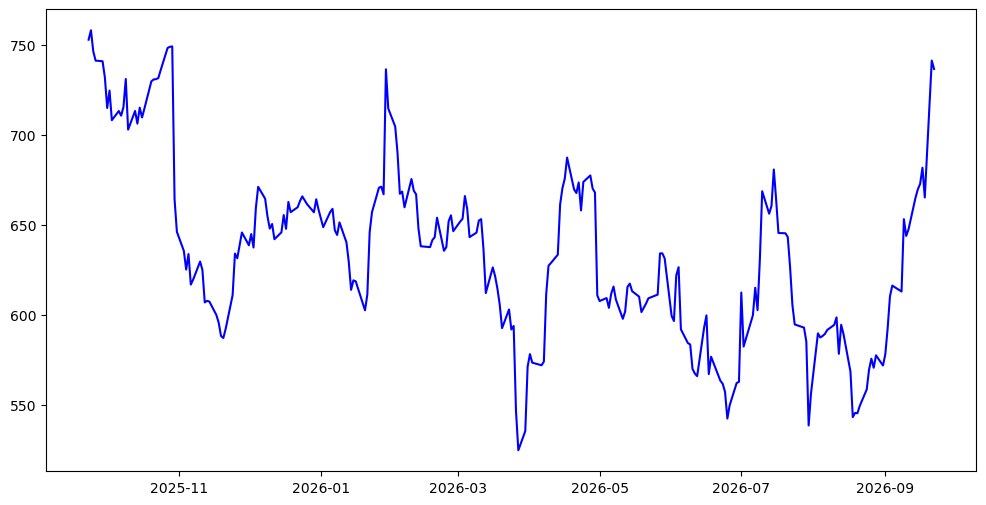

In [61]:
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices.values, label='META Closing Prices', color='blue')
plt.show()

## Opción Europea

In [42]:
S0 = df["Close"].iloc[0].item()
ST = df["Close"].iloc[-1].item()
K = S0

S0, ST, K

(591.9038696289062, 744.0999755859375, 591.9038696289062)

In [43]:
payoff_call_EU = max(ST - K, 0)

payoff_put_EU = max(K - ST, 0)

payoff_call_EU, payoff_put_EU

(152.19610595703125, 0)

## Opción Asiática

In [44]:
promedio = df["Close"].mean().item()

promedio

609.6598645307886

In [45]:
payoff_call_AS = max(promedio - K, 0)

payoff_put_AS = max(K - promedio, 0)

payoff_call_AS, payoff_put_AS

(17.75599490188233, 0)

## Opción Lookback(Flotante)

In [46]:
maximo = df["Close"].max().item()
minimo = df["Close"].min().item()

payoff_call_LB = ST - minimo
payoff_put_LB = maximo - ST

payoff_call_LB, payoff_put_LB

(219.28094482421875, 0.0)

## Simulación

In [ ]:
df = yf.download(ticker,start="2025-09-23",end="2026-09-24")

Prices = df["Close"]

rets = np.log(Prices / Prices.shift(1))
rets = rets.dropna()

Train = rets[(rets.index >= "2025-09-23") &(rets.index <= "2026-03-23")]

Test = rets[(rets.index > "2026-03-23") &(rets.index <= "2026-09-23")]

Mu = Train.mean()
Sigma = Train.std()
S0 = Prices.loc[:"2026-03-23"].iloc[-1]

M = 10000
n = 126

mu = Mu["META"]
sigma = Sigma["META"]
s0 = S0["META"]

# Simulación
np.random.seed(32)

Z = np.random.normal(0, 1, size=(M, n))

precios = np.zeros((M, n + 1))
precios[:, 0] = s0

for t in range(1, n + 1):
    precios[:, t] = precios[:, t-1] * np.exp(
        mu + sigma * Z[:, t-1]
    )



/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_78010/1923637494.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


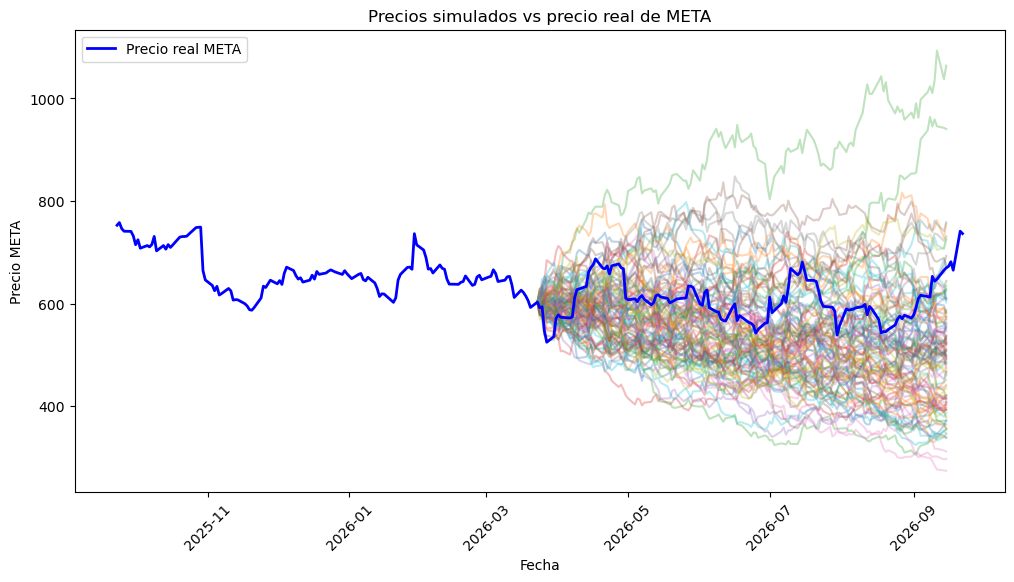

In [63]:
fechas = pd.bdate_range(
    start="2026-03-23",
    periods=n + 1
)

plt.figure(figsize=(12,6))

# 100 precios simulados
for i in range(100):
    plt.plot(fechas, precios[i], alpha=0.3)

# Precio real de META
plt.plot(
    prices.index,
    prices.values,
    label="Precio real META",
    color="blue",
    linewidth=2
)

plt.xlabel("Fecha")
plt.ylabel("Precio META")
plt.title("Precios simulados vs precio real de META")
plt.legend()
plt.xticks(rotation=45)

plt.show()